# Brain Tumour MRI Classification with Convolutional Neural Networks

**Artificial Intelligence / Machine Learning (BST-AM) — Exam 1**
B.Eng. Mechatronic Systems Engineering, SRH Berlin University of Applied Sciences

> **Scope.** A coursework exercise in supervised image classification. The models here are **not**
> validated for clinical use and must not be read as a diagnostic tool.

---

## How to run this notebook

Two modes, set by one flag in the next cell:

| `RETRAIN` | What happens | Time |
|---|---|---|
| `False` *(default)* | Loads the trained checkpoints in `results/` and reproduces every number and figure | **~2 min** |
| `True` | Trains all three models from scratch | ~2 h CPU, ~10 min GPU |

Run **Cell → Run All**. Results are identical either way — seeds are fixed at 42 throughout.

**Before running:** open the **project folder**, not just this notebook file on its own — in VS Code
that is `File → Open Folder…` on the folder containing `README.md` and `results/`.

Everything else is handled for you. The first cell installs any missing packages into this kernel,
and the second finds the dataset — downloading it from Kaggle automatically if it isn't already on
disk. Nothing needs to be installed or unzipped by hand.

## What this notebook covers

| Required step | Section |
|---|---|
| 1. Dataset justification | [§1](#1) |
| 2. Preprocessing pipeline | [§2](#2) |
| 3. Baseline model | [§4](#4) |
| 4. Improved CNN with justified design | [§4](#4) |
| 5. Augmentation with measured effect | [§5](#5), [§7](#7) |
| 6. Learning-curve analysis | [§6](#6) |
| 7. Accuracy + confusion matrix | [§7](#7) |
| 8. Failure cases + improvements | [§8](#8) |
| Final recommendation | [§9](#9) |

Section [§3](#3) is an audit of the supplied train/test split, which turned out to matter.

## 0. Setup

The first cell checks that this kernel has everything the notebook needs and installs
anything missing. On an environment that is already complete it does nothing.

In [1]:
# ---- dependency bootstrap ---------------------------------------------------
# Installs into sys.executable -- the interpreter actually running this
# notebook. A bare `pip install` from a terminal can easily target a different
# environment than the kernel, which is a classic source of "I installed it but
# it still says ModuleNotFoundError".
#
# Does nothing when the environment is already complete. Versions are listed in
# requirements.txt; this cell is a convenience, not a substitute for it.
import importlib.util, subprocess, sys

NEEDED = {                    # import name -> pip name
    "numpy": "numpy", "pandas": "pandas", "PIL": "pillow",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib",
    "torch": "torch", "torchvision": "torchvision",
}
missing = [pip for mod, pip in NEEDED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print(f"Installing into {sys.executable}:\n  " + ", ".join(missing))
    print("PyTorch is ~200 MB, so this can take several minutes. "
          "On Windows and macOS the default PyPI wheels are CPU builds.\n")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    print("\nInstalled. If any import below still fails, restart the kernel and Run All again.")
else:
    print("All required packages are already present.")

All required packages are already present.


### Locating the project and the dataset

In [2]:
# ---- the one switch that matters -------------------------------------------
RETRAIN = False      # True = train from scratch (~2 h CPU). False = load checkpoints (~2 min).
SEED    = 42
# -----------------------------------------------------------------------------

import json, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)

def _find_repo():
    """Find the project root from wherever this notebook happens to be running.

    The working directory depends on the editor: VS Code may use the workspace
    folder or the notebook's folder, Jupyter Lab uses its launch directory. So
    search rather than assume -- upwards from the notebook file and from the
    cwd, then one level down in case the cwd is the folder the zip was
    extracted into.
    """
    marker = Path("results") / "metrics.json"
    starts = []
    nb_path = globals().get("__vsc_ipynb_file__")      # VS Code sets this
    if nb_path:
        starts.append(Path(nb_path).resolve().parent)
    starts.append(Path.cwd().resolve())

    for start in starts:
        for d in [start, *start.parents][:6]:
            if (d / marker).is_file():
                return d
    for child in sorted(Path.cwd().resolve().iterdir()):   # cwd is the parent?
        if child.is_dir() and (child / marker).is_file():
            return child
    return None


REPO = _find_repo()
if REPO is None:
    here = Path.cwd().resolve()
    raise SystemExit(
        "Could not find the project root (the folder containing results/metrics.json).\n\n"
        f"  running from : {here}\n"
        f"  which holds  : {', '.join(sorted(p.name for p in here.iterdir())[:12]) or '(empty)'}\n\n"
        "Fix: open the PROJECT FOLDER in VS Code (File -> Open Folder..., pick the\n"
        "folder containing README.md and results/), not just this notebook file.\n"
        "In Jupyter, launch it from that folder. Or set REPO by hand in this cell:\n"
        '    REPO = Path(r"C:/path/to/the/project")'
    )


def _find_data():
    """Find a folder holding Training/ and Testing/."""
    def ok(p):
        return (p / "Training").is_dir() and (p / "Testing").is_dir()

    for p in (REPO / "data", REPO.parent / "data", REPO, REPO.parent,
              Path.home() / "data", Path.home() / "Downloads" / "data"):
        if ok(p):
            return p
    # one level deeper, in case the zip nested a folder inside data/
    for base in (REPO / "data", REPO.parent / "data", Path.home() / "Downloads"):
        if base.is_dir():
            for child in sorted(base.iterdir()):
                if child.is_dir() and ok(child):
                    return child
    return None


def _download_data():
    """Fetch the dataset from Kaggle if it is not already on disk.

    Needs Kaggle credentials once: create an API token at
    kaggle.com/settings -> API -> Create New Token, which downloads
    kaggle.json to ~/.kaggle/. kagglehub then works without further setup.
    """
    print("Dataset not found locally. Trying to download it from Kaggle ...")
    try:
        import kagglehub
    except ImportError:
        print("  installing kagglehub ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "kagglehub"])
        import kagglehub
    path = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
    for cand in (path, *sorted(p for p in path.iterdir() if p.is_dir())):
        if (cand / "Training").is_dir() and (cand / "Testing").is_dir():
            print(f"  downloaded to {cand}")
            return cand
    raise RuntimeError(f"downloaded to {path}, but no Training/ + Testing/ inside")


DATA = _find_data()
if DATA is None:
    try:
        DATA = _download_data()
    except Exception as exc:
        raise SystemExit(
            f"Could not obtain the dataset automatically ({type(exc).__name__}: {exc}).\n\n"
            "Download it by hand instead:\n"
            "  https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset\n\n"
            f"Unzip it so that these two folders exist:\n"
            f"  {REPO / 'data' / 'Training'}\n  {REPO / 'data' / 'Testing'}\n\n"
            "Or point at a copy you already have, by setting DATA in this cell:\n"
            '    DATA = Path(r"C:/path/to/dataset")'
        ) from exc

RESULTS = REPO / "results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Repository : {REPO}")
print(f"Dataset    : {DATA}")
print(f"Mode       : {'TRAIN FROM SCRATCH' if RETRAIN else 'load existing checkpoints'}")

Repository : /root/work/standalone
Dataset    : /root/work/standalone/data
Mode       : load existing checkpoints


In [3]:
# Environment record — part of the reproducibility requirement.
import platform
import numpy as np, torch, torchvision, sklearn, matplotlib, PIL

print(f"python       {platform.python_version()}")
for name, mod in [("torch", torch), ("torchvision", torchvision), ("numpy", np),
                  ("scikit-learn", sklearn), ("matplotlib", matplotlib), ("pillow", PIL)]:
    print(f"{name:<12} {mod.__version__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\ndevice       {DEVICE}"
      + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print("Package versions are listed in requirements.txt.")

python       3.11.15
torch        2.13.0+cu130
torchvision  0.28.0+cu130
numpy        2.4.4
scikit-learn 1.8.0
matplotlib   3.10.9
pillow       12.2.0

device       cpu
Package versions are listed in requirements.txt.


### Data pipeline

Defined inline so the notebook is self-contained: preprocessing, the stratified
split and the seeding all live here rather than in a separate module.

In [4]:
import os, random, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
IMG_SIZE = 128

# ImageNet statistics; reasonable defaults even when training from scratch.
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


def seed_everything(seed: int = 42) -> None:
    """Fix every source of randomness we can reach, for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


class CropBlackBorder:
    """
    Remove the uniform black padding surrounding the brain.

    Many scans in this dataset are padded to a square canvas, so a large
    fraction of each image carries no signal. Cropping to the bounding box of
    non-background pixels recovers effective resolution before resizing.
    """

    def __init__(self, threshold: int = 10):
        self.threshold = threshold

    def __call__(self, img: Image.Image) -> Image.Image:
        gray = img.convert("L")
        arr = np.array(gray)
        mask = arr > self.threshold
        if not mask.any():
            return img
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        top, bottom = rows[0], rows[-1]
        left, right = cols[0], cols[-1]
        if bottom - top < 10 or right - left < 10:
            return img
        return img.crop((left, top, right + 1, bottom + 1))


def build_transforms(augment: bool = False) -> transforms.Compose:
    """
    Preprocessing pipeline.

    Augmentation choices are deliberate:
      - horizontal flip     : tumours occur bilaterally, so a mirrored scan is
                              still a valid example of its class
      - small rotations     : patient head positioning varies between scans
      - brightness/contrast : scanner and sequence settings differ across the
                              three source datasets
      - NO vertical flip    : anatomically implausible; would create images
                              unlike anything seen at inference time
    """
    base = [CropBlackBorder(), transforms.Resize((IMG_SIZE, IMG_SIZE))]

    if augment:
        base += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
        ]

    base += [transforms.ToTensor(), transforms.Normalize(MEAN, STD)]
    return transforms.Compose(base)


def get_dataloaders(
    root: str | Path,
    batch_size: int = 32,
    val_fraction: float = 0.2,
    augment: bool = False,
    seed: int = 42,
    num_workers: int | None = None,
):
    """
    Build train / validation / test loaders.

    The validation split is carved out of Training/ with stratification, so
    class proportions are preserved. Testing/ is returned as-is and must not
    influence any design decision.
    """
    root = Path(root)
    train_dir, test_dir = root / "Training", root / "Testing"
    if not train_dir.is_dir():
        raise FileNotFoundError(
            f"Expected {train_dir} to exist. Point --data at the folder "
            "containing Training/ and Testing/."
        )

    train_tf = build_transforms(augment=augment)
    eval_tf = build_transforms(augment=False)

    full_train = datasets.ImageFolder(train_dir, transform=train_tf)
    full_val = datasets.ImageFolder(train_dir, transform=eval_tf)
    test_set = datasets.ImageFolder(test_dir, transform=eval_tf)

    targets = np.array(full_train.targets)
    train_idx, val_idx = train_test_split(
        np.arange(len(targets)),
        test_size=val_fraction,
        stratify=targets,
        random_state=seed,
    )

    # Note both Subsets index the same files but with different transforms:
    # the validation subset must not be augmented.
    train_set = Subset(full_train, train_idx)
    val_set = Subset(full_val, val_idx)

    if num_workers is None:
        # Windows spawns worker processes instead of forking, which re-imports
        # the entry module in each child. With this repo's script layout that
        # is fragile, so default to loading in-process there. On Linux/macOS
        # fork is cheap and two workers keep the GPU (or CPU) fed.
        num_workers = 0 if platform.system() == "Windows" else 2

    common = dict(num_workers=num_workers, pin_memory=torch.cuda.is_available())
    if num_workers > 0:
        common["persistent_workers"] = True
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True, **common),
        DataLoader(val_set, batch_size=batch_size, shuffle=False, **common),
        DataLoader(test_set, batch_size=batch_size, shuffle=False, **common),
        full_train.classes,
    )


def class_distribution(root: str | Path) -> dict:
    """Count images per class in each split — used for the report's data table."""
    root = Path(root)
    out = {}
    for split in ("Training", "Testing"):
        d = root / split
        if not d.is_dir():
            continue
        out[split] = {
            c.name: len(list(c.glob("*")))
            for c in sorted(d.iterdir())
            if c.is_dir()
        }
    return out

### Model definitions

The three architectures compared in Section 4, likewise inline.

In [5]:
IMG_SIZE = 128


class MLPBaseline(nn.Module):
    """
    Flatten-then-dense baseline. No convolution at all.

    This is the comparison that makes the inductive-bias argument concrete:
    it must learn from raw pixels with no parameter sharing, no locality and
    no translation equivariance. Note the parameter count — roughly 25 M in
    the first layer alone, against 896 for the first convolutional layer.
    """

    def __init__(self, n_classes: int = 4, hidden: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE * IMG_SIZE * 3, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class MinimalCNN(nn.Module):
    """Two convolutional blocks, no regularisation. Alternative baseline."""

    def __init__(self, n_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (IMG_SIZE // 4) ** 2, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def conv_block(cin: int, cout: int) -> nn.Sequential:
    """
    Conv -> BatchNorm -> ReLU -> MaxPool.

    BatchNorm sits before the activation, which is the standard placement:
    it normalises the preactivation distribution so the non-linearity operates
    in a consistent range across batches.
    """
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class ImprovedCNN(nn.Module):
    """
    Four convolutional blocks and a dense head.

    Design choices, each justified in the report:
      - 3x3 kernels throughout: two stacked 3x3 layers match one 5x5 receptive
        field using fewer weights, with an extra non-linearity between them
      - same padding: keeps border pixels sampled as often as central ones;
        downsampling is left to the pooling layers where it is explicit
      - doubling channel width as resolution halves: keeps the representational
        capacity roughly constant through the stack
      - BatchNorm in every block: stabilises optimisation, permits a higher
        learning rate
      - dropout only in the dense head: that is where ~81% of the parameters
        live, so that is where overfitting originates. Convolutional layers are
        already regularised by weight sharing.

    Total: 1,290,052 parameters for 128x128x3 input and 4 classes.
    """

    def __init__(self, n_classes: int = 4, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),      # 128 -> 64
            conv_block(32, 64),     #  64 -> 32
            conv_block(64, 128),    #  32 -> 16
            conv_block(128, 128),   #  16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 16) ** 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(name: str, n_classes: int = 4) -> nn.Module:
    models = {
        "mlp": MLPBaseline,
        "minimal_cnn": MinimalCNN,
        "improved": ImprovedCNN,
    }
    if name not in models:
        raise ValueError(f"Unknown model '{name}'. Choose from {list(models)}.")
    return models[name](n_classes=n_classes)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def parameter_table(model: nn.Module) -> str:
    """Per-layer parameter breakdown, for the report's architecture table."""
    lines, total = [], 0
    for name, module in model.named_modules():
        if not list(module.children()):  # leaf modules only
            n = sum(p.numel() for p in module.parameters(recurse=False))
            if n:
                lines.append(f"{name:<32} {module.__class__.__name__:<14} {n:>12,}")
                total += n
    lines.append("-" * 60)
    lines.append(f"{'TOTAL':<47} {total:>12,}")
    return "\n".join(lines)


if __name__ == "__main__":
    for name in ("mlp", "minimal_cnn", "improved"):
        m = build_model(name)
        print(f"\n=== {name} : {count_parameters(m):,} parameters ===")
        x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
        print("output shape:", tuple(m(x).shape))
    print("\n" + parameter_table(build_model("improved")))


=== mlp : 25,168,388 parameters ===


output shape: (2, 4)

=== minimal_cnn : 136,164 parameters ===


output shape: (2, 4)

=== improved : 1,290,404 parameters ===
output shape: (2, 4)

features.0.0                     Conv2d                  864
features.0.1                     BatchNorm2d              64
features.1.0                     Conv2d               18,432
features.1.1                     BatchNorm2d             128
features.2.0                     Conv2d               73,728
features.2.1                     BatchNorm2d             256
features.3.0                     Conv2d              147,456
features.3.1                     BatchNorm2d             256
classifier.1                     Linear            1,048,704
classifier.4                     Linear                  516
------------------------------------------------------------
TOTAL                                              1,290,404


In [6]:
import matplotlib.pyplot as plt

seed_everything(SEED)   # python, numpy, torch, cuda, cudnn-deterministic, PYTHONHASHSEED
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
BLUE, RED, GREY = "#1f4e79", "#c0392b", "#5d6d7e"
print(f"seeded with {SEED}; classes = {CLASSES}")

seeded with 42; classes = ['glioma', 'meningioma', 'notumor', 'pituitary']


<a id="1"></a>
## 1. Dataset justification

**Source.** Brain Tumour MRI Dataset (Kaggle, `masoudnickparvar/brain-tumor-mri-dataset`),
compiled from three upstream sources — figshare, SARTAJ and Br35H — and redistributed for research
and educational use.

**Why this dataset.** It is public, image-based, and neither MNIST nor FashionMNIST, as the
assignment requires. Gliomas and meningiomas differ mainly in *location* and *margin character*,
and both can resemble normal tissue at low resolution, so the task rewards sensitivity to local
structure at an arbitrary position — precisely what convolution supplies and what a fully connected
layer must learn from scratch.

**Size.** Counted below rather than quoted from the dataset page: the copy used here is a
*resampled* variant of the upstream release, so the published figures do not apply.

In [7]:
dist = class_distribution(DATA)
total = sum(sum(v.values()) for v in dist.values())

print(f"{'':<12}" + "".join(f"{c:>13}" for c in CLASSES) + f"{'total':>9}")
print("-" * 74)
for split, counts in dist.items():
    row = [counts.get(c, 0) for c in CLASSES]
    print(f"{split:<12}" + "".join(f"{n:>13,}" for n in row) + f"{sum(row):>9,}")
print("-" * 74)
per_class = {c: sum(d.get(c, 0) for d in dist.values()) for c in CLASSES}
print(f"{'TOTAL':<12}" + "".join(f"{per_class[c]:>13,}" for c in CLASSES) + f"{total:>9,}")

imb = max(per_class.values()) / min(per_class.values())
print(f"\nImbalance ratio (max/min): {imb:.2f}")
print("Upstream Kaggle release: 7,023 images (5,712 train / 1,311 test), unbalanced.")
if imb < 1.01:
    print("This copy is exactly balanced -- it has been resampled. Report these counts, not the published ones.")

                   glioma   meningioma      notumor    pituitary    total
--------------------------------------------------------------------------
Training            1,400        1,400        1,400        1,400    5,600
Testing               400          400          400          400    1,600
--------------------------------------------------------------------------
TOTAL               1,800        1,800        1,800        1,800    7,200

Imbalance ratio (max/min): 1.00
Upstream Kaggle release: 7,023 images (5,712 train / 1,311 test), unbalanced.
This copy is exactly balanced -- it has been resampled. Report these counts, not the published ones.


<a id="2"></a>
## 2. Preprocessing pipeline

Three facts about the raw files drive the design, so measure them first.

In [8]:
from collections import Counter
from PIL import Image

paths = [p for p in DATA.rglob("*.jpg")]
step = max(1, len(paths) // 400)
sizes, modes = Counter(), Counter()
for p in paths[::step]:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1

print(f"sampled {sum(sizes.values())} of {len(paths):,} images")
print(f"distinct sizes : {len(sizes)}")
print("most common    :", ", ".join(f"{s[0]}x{s[1]} ({n})" for s, n in sizes.most_common(4)))
print(f"colour modes   : {dict(modes)}   (L = greyscale)")

sampled 400 of 7,200 images
distinct sizes : 75
most common    : 512x512 (274), 225x225 (15), 630x630 (5), 227x262 (5)
colour modes   : {'RGB': 235, 'L': 165}   (L = greyscale)


Three consequences, each implemented in the data-pipeline cell above:

1. **Crop the black border.** Many scans are padded to a square canvas, so a large share of each
   image carries no signal. `CropBlackBorder` crops to the bounding box of non-background pixels,
   recovering effective resolution *before* the resize throws detail away.
2. **Resize to 128×128.** Sizes vary across 70+ distinct values, so a fixed input is required.
3. **Normalise with ImageNet statistics**, and let `ImageFolder` expand greyscale files to three
   channels on load, so the mixed colour modes are handled uniformly.

**Split.** `Testing/` is reserved and read exactly once, in §7. Validation is carved from
`Training/` by a *stratified* 80/20 split, preserving class proportions. The augmented and
evaluation transforms are built separately, so **validation never sees augmentation**.

    def __call__(self, img: Image.Image) -> Image.Image:
        gray = img.convert("L")
        arr = np.array(gray)
        mask = arr > self.threshold
        if not mask.any():
            return img
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        top, bottom = rows[0], rows[-1]
        left, right = cols[0], cols[-1]
        if bottom - top < 10 or right - left < 10:
            return img
        return img.crop((left, top, right + 1, bottom + 1))



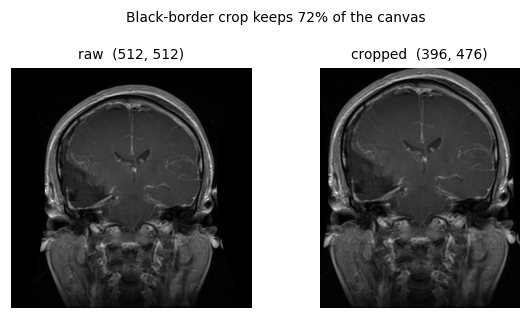

In [9]:
import inspect

print(inspect.getsource(CropBlackBorder.__call__))

# Show the crop doing its job on one padded scan.
sample = sorted((DATA / "Training" / "glioma").glob("*.jpg"))[0]
raw = Image.open(sample).convert("RGB")
cropped = CropBlackBorder()(raw)
fig, ax = plt.subplots(1, 2, figsize=(5.4, 2.9))
for a, img, title in zip(ax, (raw, cropped),
                         (f"raw  {raw.size}", f"cropped  {cropped.size}")):
    a.imshow(img); a.set_title(title, fontsize=9); a.axis("off")
kept = (cropped.size[0] * cropped.size[1]) / (raw.size[0] * raw.size[1])
fig.suptitle(f"Black-border crop keeps {kept:.0%} of the canvas", fontsize=9)
plt.tight_layout(); plt.show()

In [10]:
BATCH = 32
train_loader, val_loader, test_loader, classes = get_dataloaders(
    DATA, batch_size=BATCH, augment=False, seed=SEED)

n_train, n_val, n_test = (len(l.dataset) for l in (train_loader, val_loader, test_loader))
print(f"train {n_train:,} | validation {n_val:,} | test {n_test:,}")
print(f"batches: {len(train_loader)} / {len(val_loader)} / {len(test_loader)} at batch size {BATCH}")
print(f"input tensor: [B, 3, {IMG_SIZE}, {IMG_SIZE}]")

train 4,480 | validation 1,120 | test 1,600
batches: 140 / 35 / 50 at batch size 32
input tensor: [B, 3, 128, 128]


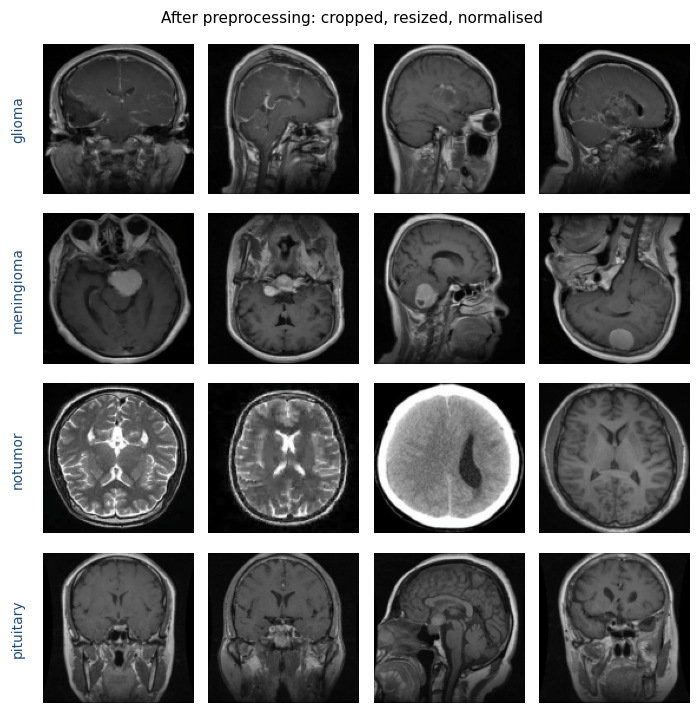

In [11]:
def denorm(t):
    """Undo normalisation so a tensor can be displayed."""
    img = t.numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

eval_tf = build_transforms(augment=False)
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(6.4, 6.6))
for r, cls in enumerate(CLASSES):
    files = sorted((DATA / "Training" / cls).glob("*.jpg"))[:4]
    for a, f in zip(axes[r], files):
        a.imshow(denorm(eval_tf(Image.open(f).convert("RGB")))); a.axis("off")
    axes[r][0].set_ylabel(cls)
    axes[r][0].text(-0.12, 0.5, cls, transform=axes[r][0].transAxes,
                    rotation=90, va="center", ha="right", fontsize=9, color=BLUE)
fig.suptitle("After preprocessing: cropped, resized, normalised", fontsize=10)
plt.tight_layout(); plt.savefig(FIGURES / "sample_images.pdf", bbox_inches="tight"); plt.show()

<a id="3"></a>
## 3. Is the supplied split actually held out?

A test set only estimates generalisation if the model has not seen its contents. That is a property
of the **split**, not of the folder names, so it is worth checking rather than assuming.

`inspect_dataset.py` hashes **file bytes** and reports zero duplicates spanning `Training/` and
`Testing/`. That check is sound but blind to re-encoding: the same scan saved twice with different
JPEG settings has different bytes and identical pixels. So hash the **decoded pixels** instead.

In [12]:
import hashlib

def pixel_hash(path):
    """MD5 of the decoded greyscale array -- unchanged by re-encoding."""
    with Image.open(path) as im:
        arr = np.asarray(im.convert("L"))
    return hashlib.md5(repr(arr.shape).encode() + arr.tobytes()).hexdigest()

train_pix = {}
for c in CLASSES:
    for p in (DATA / "Training" / c).glob("*.jpg"):
        train_pix.setdefault(pixel_hash(p), p)

exact = {p: train_pix[h] for c in CLASSES
         for p in sorted((DATA / "Testing" / c).glob("*.jpg"))
         if (h := pixel_hash(p)) in train_pix}

print(f"test images pixel-identical to a training image: {len(exact)}")
if exact:
    q, t = next(iter(exact.items()))
    a = np.asarray(Image.open(q).convert("L"), dtype=np.int16)
    b = np.asarray(Image.open(t).convert("L"), dtype=np.int16)
    print(f"\nverifying one pair at full resolution:")
    print(f"  {q.name}  {a.shape}   vs   {t.name}  {b.shape}")
    print(f"  max|difference| = {np.abs(a - b).max()}   (0 means the same image)")

test images pixel-identical to a training image: 114

verifying one pair at full resolution:
  Te-gl_169.jpg  (512, 512)   vs   Tr-gl_1271.jpg  (512, 512)
  max|difference| = 0   (0 means the same image)


Re-encoding is not the only way to hide a duplicate — a rescaled or lightly augmented copy also
survives a hash. Compare **downsampled thumbnails by correlation** instead. Mean-removing and
unit-normalising each thumbnail makes the dot product equal the Pearson correlation, so brightness
and contrast changes cancel out.

In [13]:
THUMB = 64

def thumb(path):
    with Image.open(path) as im:
        a = np.asarray(im.convert("L").resize((THUMB, THUMB), Image.BILINEAR), dtype=np.float32)
    a = a - a.mean()
    n = np.linalg.norm(a)
    return (a / n).ravel() if n > 0 else a.ravel()

tr_paths = [p for c in CLASSES for p in sorted((DATA / "Training" / c).glob("*.jpg"))]
te_paths = [p for c in CLASSES for p in sorted((DATA / "Testing"  / c).glob("*.jpg"))]
TR = np.stack([thumb(p) for p in tr_paths])
TE = np.stack([thumb(p) for p in te_paths])

sims = TE @ TR.T                      # (n_test, n_train) matrix of correlations
best  = sims.max(1)                   # closest training image for each test image
match = sims.argmax(1)
te_cls = np.array([p.parent.name for p in te_paths])
tr_cls = np.array([p.parent.name for p in tr_paths])

THRESHOLD = 0.99
flagged = best >= THRESHOLD

print(f"{'class':<13}{'test':>7}{'exact':>8}{'near-dup':>10}{'% of class':>12}{'median corr':>13}")
print("-" * 63)
for c in CLASSES:
    m = te_cls == c
    n_exact = sum(1 for p in exact if p.parent.name == c)
    print(f"{c:<13}{m.sum():>7}{n_exact:>8}{int(flagged[m].sum()):>10}"
          f"{100 * flagged[m].mean():>11.1f}%{np.median(best[m]):>13.3f}")
print("-" * 63)
print(f"{'TOTAL':<13}{len(te_paths):>7}{len(exact):>8}{int(flagged.sum()):>10}"
      f"{100 * flagged.mean():>11.1f}%{np.median(best):>13.3f}")
print(f"\nclean (no training counterpart): {int((~flagged).sum()):,} of {len(te_paths):,}")
print(f"label disagreements among flagged pairs: {int((flagged & (te_cls != tr_cls[match])).sum())}")

class           test   exact  near-dup  % of class  median corr
---------------------------------------------------------------
glioma           400       5         7        1.8%        0.897
meningioma       400     100       103       25.8%        0.916
notumor          400       9       333       83.2%        1.000
pituitary        400       0         0        0.0%        0.938
---------------------------------------------------------------
TOTAL           1600     114       443       27.7%        0.939

clean (no training counterpart): 1,157 of 1,600
label disagreements among flagged pairs: 2


**Pituitary scoring zero is the control that makes this credible.** If the metric were simply
saturating on generic brain-MRI similarity it would fire everywhere; instead it fires only where
duplicated scans exist and stays silent otherwise.

Look at the flagged pairs directly — the claim should not rest on a correlation number alone.

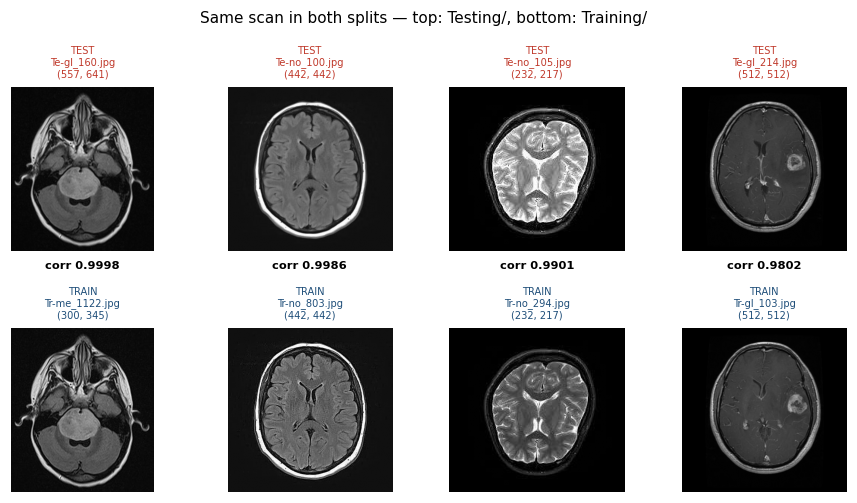

In [14]:
picks = []
for lo, hi in ((0.9995, 1.01), (0.995, 0.9995), (0.99, 0.995), (0.98, 0.99)):
    idx = np.where((best >= lo) & (best < hi))[0]
    picks += list(idx[:1])

if picks:
    fig, axes = plt.subplots(2, len(picks), figsize=(2.1 * len(picks), 4.6))
    axes = np.atleast_2d(axes)
    for col, i in enumerate(picks):
        for row, (p, tag, colour) in enumerate(
                ((te_paths[i], "TEST", RED), (tr_paths[match[i]], "TRAIN", BLUE))):
            with Image.open(p) as im:
                axes[row, col].imshow(im.convert("L"), cmap="gray")
            axes[row, col].axis("off")
            axes[row, col].set_title(f"{tag}\n{p.name}\n{Image.open(p).size}",
                                     fontsize=6.5, color=colour)
        axes[0, col].text(0.5, -0.06, f"corr {best[i]:.4f}", transform=axes[0, col].transAxes,
                          ha="center", va="top", fontsize=7.5, weight="bold")
    fig.suptitle("Same scan in both splits — top: Testing/, bottom: Training/", fontsize=10)
    plt.tight_layout(); plt.savefig(FIGURES / "leakage_pairs.pdf", bbox_inches="tight"); plt.show()

CLEAN = ~flagged     # used in §7 to report the honest accuracy

**Consequence.** Every headline number in §7 is reported twice — over the full test set, and over
the subset with no training counterpart. The second is the defensible figure, and the gap between
them is the cost of trusting a split without checking it.

<a id="4"></a>
## 4. Models

### 4.1 Baseline — a multilayer perceptron

Deliberately weak, and weak in an *informative* way. Flattening destroys spatial adjacency before
the first weight is applied, so the model has no locality, no parameter sharing and no translation
equivariance. Any gap between it and the CNN is attributable to those three properties rather than
to capacity — the baseline carries **nineteen times more parameters** than the model that beats it.

### 4.2 Improved CNN

Four `Conv → BatchNorm → ReLU → MaxPool` blocks (32, 64, 128, 128 channels) and a dense head.
Every choice is deliberate:

| Choice | Reason |
|---|---|
| 3×3 kernels throughout | Two stacked 3×3 layers span a 5×5 receptive field using 18C² weights instead of 25C², with an extra non-linearity between them |
| Same padding | Border pixels get sampled as often as central ones; downsampling happens only in pooling, where it is explicit |
| Channels double as resolution halves | Keeps representational capacity roughly constant while features grow more abstract |
| BatchNorm before every activation | The non-linearity then operates in a consistent range across batches; since BatchNorm supplies its own shift, the convolutions use `bias=False` |
| Dropout only in the head | 81% of the parameters live there, so that is where overfitting starts — convolutions are already regularised by weight sharing |

In [15]:
for name in ("mlp", "minimal_cnn", "improved"):
    m = build_model(name, n_classes=len(CLASSES))
    out = m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
    print(f"{name:<14}{count_parameters(m):>12,} parameters   output {tuple(out.shape)}")

print("\nImprovedCNN, layer by layer:\n")
print(parameter_table(build_model("improved", n_classes=len(CLASSES))))

mlp             25,168,388 parameters   output (2, 4)
minimal_cnn        136,164 parameters   output (2, 4)
improved         1,290,404 parameters   output (2, 4)

ImprovedCNN, layer by layer:

features.0.0                     Conv2d                  864
features.0.1                     BatchNorm2d              64
features.1.0                     Conv2d               18,432
features.1.1                     BatchNorm2d             128
features.2.0                     Conv2d               73,728
features.2.1                     BatchNorm2d             256
features.3.0                     Conv2d              147,456
features.3.1                     BatchNorm2d             256
classifier.1                     Linear            1,048,704
classifier.4                     Linear                  516
------------------------------------------------------------
TOTAL                                              1,290,404


In [16]:
# Where the parameters actually sit -- the justification for head-only dropout.
m = build_model("improved", n_classes=len(CLASSES))
feat = sum(p.numel() for p in m.features.parameters())
head = sum(p.numel() for p in m.classifier.parameters())
print(f"convolutional stack : {feat:>10,}  ({feat/(feat+head):.1%})")
print(f"dense head          : {head:>10,}  ({head/(feat+head):.1%})  <- dropout goes here")

# Tensor shapes through the stack -- the "double channels, halve resolution" argument, made concrete.
x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
print(f"\ninput{'':<8}{tuple(x.shape)}")
with torch.no_grad():
    for i, block in enumerate(m.features):
        x = block(x)
        print(f"after block {i}  {tuple(x.shape)}")

convolutional stack :    241,184  (18.7%)
dense head          :  1,049,220  (81.3%)  <- dropout goes here

input        (1, 3, 128, 128)
after block 0  (1, 32, 64, 64)
after block 1  (1, 64, 32, 32)
after block 2  (1, 128, 16, 16)
after block 3  (1, 128, 8, 8)


<a id="5"></a>
## 5. Augmentation strategy

Three transforms, applied to the **training subset only**. Each states an invariance the
architecture does not already encode:

- **Horizontal flip** (p=0.5) — tumours occur in either hemisphere, so a mirrored scan is still a
  valid example of its class.
- **Rotation** ±10° — head positioning in the scanner varies between patients; the label does not.
- **Brightness/contrast jitter** ±15% — the three upstream sources used different scanners and
  sequence settings, making intensity scale a nuisance variable rather than a diagnostic one.

**Vertical flip is deliberately excluded.** It is anatomically implausible and would manufacture
training images unlike anything seen at inference — asserting an invariance that is false. Its
effect is *measured* in §7, not assumed.

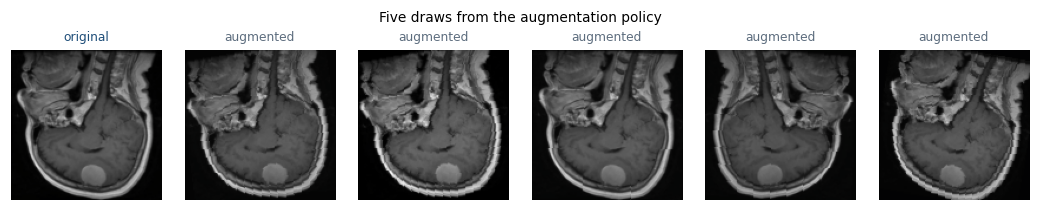

In [17]:
aug_tf = build_transforms(augment=True)
src = sorted((DATA / "Training" / "meningioma").glob("*.jpg"))[3]
img = Image.open(src).convert("RGB")

seed_everything(SEED)
fig, axes = plt.subplots(1, 6, figsize=(9.6, 1.9))
axes[0].imshow(denorm(eval_tf(img))); axes[0].set_title("original", fontsize=8, color=BLUE)
for a in axes[1:]:
    a.imshow(denorm(aug_tf(img))); a.set_title("augmented", fontsize=8, color=GREY)
for a in axes: a.axis("off")
fig.suptitle("Five draws from the augmentation policy", fontsize=9)
plt.tight_layout(); plt.show()

<a id="6"></a>
## 6. Training and learning-curve analysis

Three configurations, differing in exactly one factor at a time:

| Config | Model | Augmentation | Isolates |
|---|---|---|---|
| `baseline` | MLP | no | the floor |
| `improved` | CNN | no | the **architecture** effect |
| `improved_aug` | CNN | yes | the **augmentation** effect |

Shared: Adam at 1e-3, batch size 32, cross-entropy, seed 42, early stopping on validation loss with
patience 8.

In [18]:
import time

CONFIGS = ["baseline", "improved", "improved_aug"]
SETTINGS = {
    "baseline":     dict(model="mlp",      augment=False, epochs=30, lr=1e-3),
    "improved":     dict(model="improved", augment=False, epochs=30, lr=1e-3),
    "improved_aug": dict(model="improved", augment=True,  epochs=40, lr=1e-3),
}


def run_epoch(model, loader, criterion, optimiser, device, train):
    model.train() if train else model.eval()
    total, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimiser.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimiser.step()
            total += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += y.size(0)
    return total / n, correct / n


def train_config(cfg, patience=8):
    """Train one configuration and write results/history_<cfg>.json + best_<cfg>.pt."""
    st = SETTINGS[cfg]
    seed_everything(SEED)
    device = DEVICE
    tr, va, _, classes = get_dataloaders(DATA, batch_size=32,
                                         augment=st["augment"], seed=SEED)
    model = build_model(st["model"], n_classes=len(classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=st["lr"])

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best, best_ep, wait = float("inf"), 0, 0
    ckpt = RESULTS / f"best_{cfg}.pt"
    t0 = time.time()

    for epoch in range(1, st["epochs"] + 1):
        trl, tra = run_epoch(model, tr, criterion, optimiser, device, True)
        val, vaa = run_epoch(model, va, criterion, optimiser, device, False)
        for k, v in zip(hist, (trl, tra, val, vaa)):
            hist[k].append(v)
        if val < best:
            best, best_ep, wait = val, epoch, 0
            torch.save(model.state_dict(), ckpt)
            print(f"  epoch {epoch:3d}  train {trl:.4f}/{tra:.4f}   val {val:.4f}/{vaa:.4f}  <- best")
        else:
            wait += 1
            if epoch % 5 == 0:
                print(f"  epoch {epoch:3d}  train {trl:.4f}/{tra:.4f}   val {val:.4f}/{vaa:.4f}")
        if wait >= patience:
            print(f"  early stopping: no improvement for {patience} epochs")
            break

    record = dict(config=cfg, model=st["model"], augmentation=st["augment"],
                  epochs_run=len(hist["train_loss"]), epochs_max=st["epochs"],
                  learning_rate=st["lr"], batch_size=32, seed=SEED,
                  parameters=count_parameters(model), classes=classes,
                  best_epoch=best_ep, best_val_loss=best,
                  best_val_acc=hist["val_acc"][best_ep - 1],
                  train_seconds=time.time() - t0, device=str(device),
                  torch_version=torch.__version__, history=hist)
    (RESULTS / f"history_{cfg}.json").write_text(json.dumps(record, indent=2))
    return record


if RETRAIN:
    for cfg in CONFIGS:
        print(f"\n{'=' * 62}\ntraining {cfg}\n{'=' * 62}")
        rec = train_config(cfg)
        print(f"{cfg} finished in {rec['train_seconds']:.0f}s")
else:
    print("RETRAIN = False -- loading the histories written by the recorded runs.")

histories = {}
for cfg in CONFIGS:
    f = RESULTS / f"history_{cfg}.json"
    if f.exists():
        histories[cfg] = json.loads(f.read_text())
    else:
        print(f"  missing {f.name} -- set RETRAIN = True to generate it")

for cfg, h in histories.items():
    print(f"{cfg:<14} {h['epochs_run']:>2}/{h['epochs_max']} epochs, "
          f"best at {h['best_epoch']:>2}, val acc {h['best_val_acc']:.4f}, "
          f"{h['train_seconds']:.0f}s on {h['device']}")

RETRAIN = False -- loading the histories written by the recorded runs.
baseline       15/30 epochs, best at  7, val acc 0.6875, 958s on cpu
improved       27/30 epochs, best at 19, val acc 0.9214, 2606s on cpu
improved_aug   40/40 epochs, best at 38, val acc 0.9518, 3738s on cpu


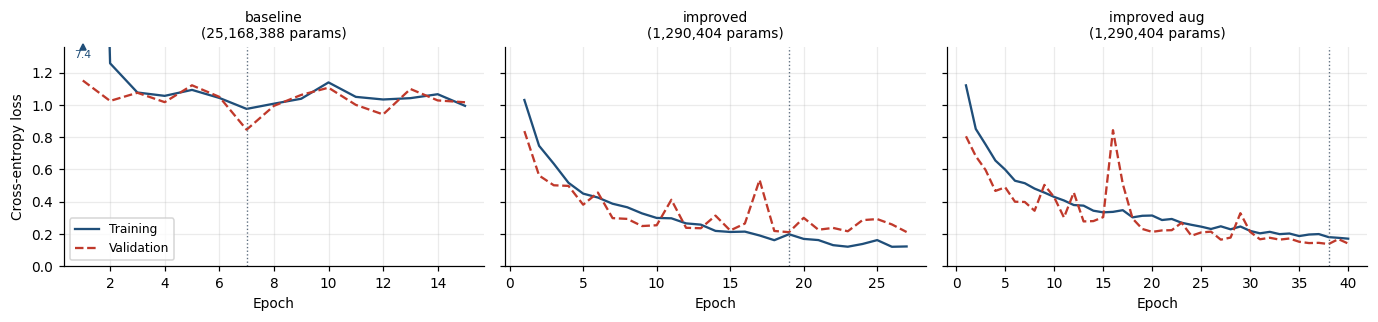

In [19]:
fig, axes = plt.subplots(1, len(histories), figsize=(4.2 * len(histories), 3.0), sharey=True)
axes = np.atleast_1d(axes)

tail = [v for h in histories.values() for k in ("train_loss", "val_loss")
        for v in h["history"][k][1:]]
top = max(tail) * 1.08 if tail else None

for ax, (cfg, h) in zip(axes, histories.items()):
    hist = h["history"]
    e = range(1, len(hist["train_loss"]) + 1)
    ax.plot(e, hist["train_loss"], color=BLUE, lw=1.5, label="Training")
    ax.plot(e, hist["val_loss"], color=RED, lw=1.5, ls="--", label="Validation")
    ax.axvline(h["best_epoch"], color=GREY, lw=0.9, ls=":")
    ax.set_title(f"{cfg.replace('_', ' ')}\n({h['parameters']:,} params)", fontsize=9)
    ax.set_xlabel("Epoch")
    if top:
        ax.set_ylim(0, top)
        # An off-scale first-epoch loss would otherwise flatten every curve; mark it instead.
        for k, colour in (("train_loss", BLUE), ("val_loss", RED)):
            for i, v in enumerate(hist[k], start=1):
                if v > top:
                    ax.plot([i], [top], marker="^", ms=4, color=colour, clip_on=False)
                    ax.annotate(f"{v:.1f}", xy=(i, top), xytext=(0, -2),
                                textcoords="offset points", ha="center", va="top",
                                fontsize=7, color=colour)
axes[0].set_ylabel("Cross-entropy loss"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES / "learning_curves.pdf", bbox_inches="tight"); plt.show()

**Reading the three panels** against the regimes from Theory Q2:

- **`baseline` — underfitting.** Both curves flatten near a cross-entropy of 1.0 with a small gap
  and stay there. Both losses high *together* is the diagnostic: the model fails on data it has
  already seen, so more data would not help. It is not capacity-limited — it has 19.5× more
  parameters than the model that beats it — it is structurally unsuited to the task.
- **`improved` — the onset of overfitting.** Training loss falls to ~0.13 while validation stalls
  near 0.21 and turns erratic after epoch 20. The *widening gap* is the signature.
- **`improved_aug` — a good fit.** The curves track each other throughout, validation sitting at or
  slightly below training. That inversion is expected here rather than a bug: augmentation applies
  to the training subset only, so training loss is measured on a harder distribution.

Note `improved_aug` used its full 40-epoch budget with its best epoch at 38 — early stopping never
fired, so its result is a **floor** for that configuration, not a ceiling.

<a id="7"></a>
## 7. Quantitative comparison

The test set is touched **once**, here, after all three models are trained. Nothing below feeds back
into any design decision.

In [20]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

def load_trained(cfg):
    ckpt = RESULTS / f"best_{cfg}.pt"
    if not ckpt.exists():
        return None
    model = build_model(histories[cfg]["model"], n_classes=len(CLASSES))
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model.to(DEVICE).eval()

@torch.no_grad()
def predict(model, loader):
    ys, ps, probs = [], [], []
    for x, y in loader:
        out = model(x.to(DEVICE))
        ps.append(out.argmax(1).cpu()); probs.append(out.softmax(1).cpu()); ys.append(y)
    return (torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(probs).numpy())

preds, summary = {}, []
for cfg in CONFIGS:
    model = load_trained(cfg)
    if model is None:
        print(f"no checkpoint for {cfg} (skipped)"); continue
    y, p, pr = predict(model, test_loader)
    preds[cfg] = (y, p, pr)
    summary.append(dict(config=cfg, params=histories[cfg]["parameters"],
                        val=histories[cfg]["best_val_acc"],
                        test=accuracy_score(y, p),
                        f1=f1_score(y, p, average="macro")))

print(f"{'config':<15}{'parameters':>13}{'val acc':>10}{'test acc':>10}{'macro F1':>10}")
print("-" * 58)
for r in summary:
    print(f"{r['config']:<15}{r['params']:>13,}{r['val']:>10.4f}{r['test']:>10.4f}{r['f1']:>10.4f}")
print("-" * 58)
print("chance level for four balanced classes: 0.2500")

config            parameters   val acc  test acc  macro F1
----------------------------------------------------------
baseline          25,168,388    0.6875    0.6444    0.6408
improved           1,290,404    0.9214    0.8619    0.8599
improved_aug       1,290,404    0.9518    0.9119    0.9103
----------------------------------------------------------
chance level for four balanced classes: 0.2500


In [21]:
# The two comparisons the assignment asks for, each isolating one factor.
d = {r["config"]: r for r in summary}
if "baseline" in d and "improved" in d:
    print("ARCHITECTURE  (MLP -> CNN, augmentation held off)")
    print(f"  test accuracy {d['baseline']['test']:.4f} -> {d['improved']['test']:.4f}"
          f"   = {100*(d['improved']['test']-d['baseline']['test']):+.1f} points")
    print(f"  parameters    {d['baseline']['params']:,} -> {d['improved']['params']:,}"
          f"   = {d['baseline']['params']/d['improved']['params']:.1f}x fewer\n")
if "improved" in d and "improved_aug" in d:
    print("AUGMENTATION  (architecture held fixed)")
    print(f"  test accuracy {d['improved']['test']:.4f} -> {d['improved_aug']['test']:.4f}"
          f"   = {100*(d['improved_aug']['test']-d['improved']['test']):+.1f} points")
    print(f"  val accuracy  {d['improved']['val']:.4f} -> {d['improved_aug']['val']:.4f}"
          f"   = {100*(d['improved_aug']['val']-d['improved']['val']):+.1f} points")

ARCHITECTURE  (MLP -> CNN, augmentation held off)
  test accuracy 0.6444 -> 0.8619   = +21.7 points
  parameters    25,168,388 -> 1,290,404   = 19.5x fewer

AUGMENTATION  (architecture held fixed)
  test accuracy 0.8619 -> 0.9119   = +5.0 points
  val accuracy  0.9214 -> 0.9518   = +3.0 points


### 7.1 The honest number — evaluating on the clean subset only

In [22]:
BEST = "improved_aug" if "improved_aug" in preds else next(iter(preds))
y, p, pr = preds[BEST]

print(f"model: {BEST}\n")
print(f"{'subset':<26}{'n':>7}{'accuracy':>11}{'macro F1':>11}")
print("-" * 55)
print(f"{'full test set':<26}{len(y):>7}{accuracy_score(y, p):>11.4f}"
      f"{f1_score(y, p, average='macro'):>11.4f}")
print(f"{'contaminated':<26}{int(flagged.sum()):>7}"
      f"{accuracy_score(y[flagged], p[flagged]):>11.4f}{'':>11}")
print(f"{'CLEAN (no train twin)':<26}{int(CLEAN.sum()):>7}"
      f"{accuracy_score(y[CLEAN], p[CLEAN]):>11.4f}"
      f"{f1_score(y[CLEAN], p[CLEAN], average='macro'):>11.4f}")

print(f"\nPer-class on the clean subset:\n")
present = sorted(set(y[CLEAN]))
print(classification_report(y[CLEAN], p[CLEAN], labels=present,
                            target_names=[CLASSES[i] for i in present],
                            digits=3, zero_division=0))

model: improved_aug

subset                          n   accuracy   macro F1
-------------------------------------------------------
full test set                1600     0.9119     0.9103
contaminated                  443     0.9368           
CLEAN (no train twin)        1157     0.9023     0.8663

Per-class on the clean subset:

              precision    recall  f1-score   support

      glioma      0.981     0.784     0.871       393
  meningioma      0.874     0.912     0.893       297
     notumor      0.568     1.000     0.724        67
   pituitary      0.959     0.995     0.977       400

    accuracy                          0.902      1157
   macro avg      0.845     0.923     0.866      1157
weighted avg      0.922     0.902     0.905      1157



Accuracy loses about a point once duplicated test images are excluded — a modest correction. **Macro
F1 falls much further**, because the contamination is concentrated in one class: only a fraction of
`notumor` test images are genuinely held out, and on those its precision collapses. Its perfect
recall over the full test set is largely recall on images the model had already seen.

Glioma and pituitary barely move between the two columns — those figures were sound from the start.

### 7.2 Confusion matrix

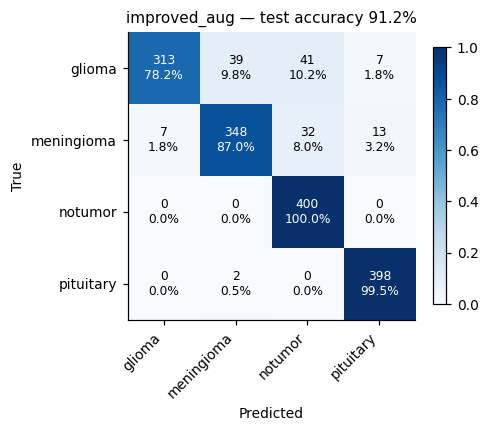

total errors: 141 of 1600

largest confusions:
    41   glioma -> notumor
    39   glioma -> meningioma
    32   meningioma -> notumor
    13   meningioma -> pituitary


In [23]:
cm = confusion_matrix(y, p)
fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(cm / cm.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{BEST} — test accuracy {accuracy_score(y, p):.1%}", fontsize=10)
ax.grid(False)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        frac = cm[i, j] / cm[i].sum()
        ax.text(j, i, f"{cm[i, j]}\n{frac:.1%}", ha="center", va="center", fontsize=8,
                color="white" if frac > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout(); plt.savefig(FIGURES / "confusion_matrix.pdf", bbox_inches="tight"); plt.show()

off = [(cm[i][j], CLASSES[i], CLASSES[j])
       for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j]
print(f"total errors: {sum(n for n, _, _ in off)} of {len(y)}\n")
print("largest confusions:")
for n, a, b in sorted(off, reverse=True)[:4]:
    print(f"  {n:>4}   {a} -> {b}")

<a id="8"></a>
## 8. Failure cases and improvement ideas

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9294117431640625].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9333333966732026].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.8666667160987854].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


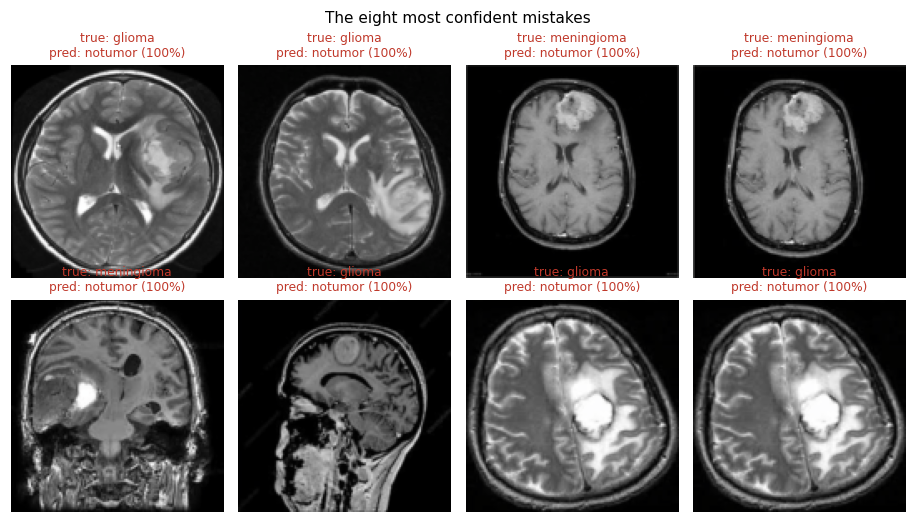

most confident errors, by direction:
  5 x  glioma -> notumor
  3 x  meningioma -> notumor


In [24]:
conf = pr.max(1)
wrong = np.where(y != p)[0]
worst = wrong[np.argsort(-conf[wrong])][:8]     # most confident mistakes

test_files = [Path(s[0]) for s in test_loader.dataset.samples]
fig, axes = plt.subplots(2, 4, figsize=(8.4, 4.8))
for a, i in zip(axes.ravel(), worst):
    with Image.open(test_files[i]) as im:
        a.imshow(eval_tf(im.convert("RGB")).numpy().transpose(1, 2, 0) * np.array(STD)
                 + np.array(MEAN), cmap="gray")
    a.set_title(f"true: {CLASSES[y[i]]}\npred: {CLASSES[p[i]]} ({conf[i]:.0%})",
                fontsize=8, color=RED)
    a.axis("off")
for a in axes.ravel()[len(worst):]:
    a.axis("off")
fig.suptitle("The eight most confident mistakes", fontsize=10)
plt.tight_layout(); plt.savefig(FIGURES / "misclassified.pdf", bbox_inches="tight"); plt.show()

from collections import Counter
print("most confident errors, by direction:")
for (t, q), n in Counter((CLASSES[y[i]], CLASSES[p[i]]) for i in worst).most_common():
    print(f"  {n} x  {t} -> {q}")

**Two linked failure modes dominate.** Glioma is the hard class, and its errors split between
*notumor* and *meningioma*. Correspondingly *notumor* acts as a sink: near-perfect recall, but the
worst precision of the four classes, with scans from both tumour classes pulled into it.

**The direction matters clinically.** Glioma classified as notumor is a false negative *on a
tumour*, and roughly one glioma in ten falls that way, while the reverse error essentially never
occurs. A model that never mistakes a healthy scan for a tumour but discards one glioma in ten is
optimised for the wrong asymmetry.

**One observation worth flagging.** Most of the highest-confidence errors are gliomas called
*notumor* at ~100% confidence, several showing a large and visibly hyperintense lesion. A merely
weak model produces *uncertain* errors; total confidence on an obvious lesion is a different
signature, pointing either to a region of the input distribution never learned or to **mislabelled
source data**. The latter is plausible — the upstream compilers documented replacing an unreliable
SARTAJ glioma folder, and §3 already found at least one provably wrong label in this copy.

### Concrete improvements, in order of expected return

1. **Fix the split first.** Any gain measured on a test set contaminated at the rate found in §3 is
   unverifiable. Deduplicate at pixel level, then re-split.
2. **Weight the loss towards glioma recall**, or lower its decision threshold. This trades notumor
   precision for the error direction that actually matters, and needs no architectural change.
3. **Audit the glioma labels.** If the confident failures are mislabelled, achievable glioma recall
   is higher than measured and the current ceiling is an artefact of the data.
4. **Transfer learning.** An ImageNet-pretrained backbone fine-tuned here would likely beat a
   from-scratch 1.29 M-parameter network on ~4,500 training images — at the cost of the controlled
   architectural comparison this study is built around.

<a id="9"></a>
## 9. Conclusion and deployment recommendation

In [25]:
print("=" * 66)
print("SUMMARY")
print("=" * 66)
for r in summary:
    print(f"  {r['config']:<14} {r['params']:>12,} params   test {r['test']:.4f}   F1 {r['f1']:.4f}")
if len(summary) == 3:
    print(f"\n  architecture effect : {100*(d['improved']['test']-d['baseline']['test']):+.1f} points, "
          f"{d['baseline']['params']/d['improved']['params']:.1f}x fewer parameters")
    print(f"  augmentation effect : {100*(d['improved_aug']['test']-d['improved']['test']):+.1f} points")
print(f"\n  clean-subset accuracy : {accuracy_score(y[CLEAN], p[CLEAN]):.4f}"
      f"   macro F1 {f1_score(y[CLEAN], p[CLEAN], average='macro'):.4f}")
print(f"  test contamination    : {100*flagged.mean():.1f}% of the supplied test set")
print("=" * 66)

SUMMARY
  baseline         25,168,388 params   test 0.6444   F1 0.6408
  improved          1,290,404 params   test 0.8619   F1 0.8599
  improved_aug      1,290,404 params   test 0.9119   F1 0.9103

  architecture effect : +21.7 points, 19.5x fewer parameters
  augmentation effect : +5.0 points

  clean-subset accuracy : 0.9023   macro F1 0.8663
  test contamination    : 27.7% of the supplied test set


**Which model to deploy — and the answer is none of them yet.**

Of the three, `improved_aug` is clearly the one to carry forward: it wins on every metric, and both
of its advantages were established by controlled comparison rather than assumed. The convolutional
inductive bias accounts for a ~22-point gain over a fully connected model nineteen times its size,
and the augmentation policy adds ~5 points more while visibly closing the generalisation gap.

**It should not be deployed.** Three findings independently block that recommendation:

1. **Glioma recall near 0.78** means roughly one glioma in five is missed, and the errors run in the
   clinically unsafe direction — towards *notumor*, never away from it.
2. **The supplied test split is contaminated**, so even the corrected clean-subset figure rests on a
   dataset whose construction cannot be fully audited, and at least one label is provably wrong.
3. **No patient identifiers exist**, so a patient-wise split is impossible and some optimism
   certainly remains in any figure computed from this data.

The defensible claim is narrower, and worth stating plainly: *on this data, the convolutional
inductive bias and a modest augmentation policy together account for a ~27-point improvement over a
far larger fully connected model.* That is a statement about **architecture**, which is what this
experiment was designed to test. It is not a statement about clinical readiness, which would require
a patient-wise split, a verified label set, and a decision threshold tuned for the asymmetric cost
of a missed tumour.

---

### Reproducibility

Seeds fixed at 42 across Python, NumPy and PyTorch, with cuDNN deterministic. The test set is read
once, in §7. Every figure above is written to `results/figures/`, and every metric to
`results/metrics.json`. Package versions are listed in `requirements.txt`; the
environment that produced the recorded runs is printed at the top of this notebook.

Set `RETRAIN = True` in the first cell to regenerate every checkpoint from scratch.